# Combos of optimisation steps
 - odt
 - lloyd
 - perturb
 - exude


In [1]:
import subprocess

## Figure out sensible iteration limits 

#### ODT
 - time_limit = 180
 - iterations = [1, 10, 100]
 - convergence = 0
 - freeze_bound = 0.001

In [2]:
path_MeshPipeline_main = '../../../../MeshPipeline/main.py'
subprocess.run(["python", path_MeshPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/set_parameters/parameters.json


Full parameter file saved to outputs/optCombos-study1/odt/params/full_params.json

SUBJECT: 50037L
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 6.893s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 10.692s - ok
		STEP: 3Dmesh
			RUN ID: -0-0-0
			Runtime: 16.293s - ok
			RUN ID: -0-0-1
			Runtime: 29.598s - ok
			RUN ID: -0-0-2
			Runtime: 65.379s - ok


CompletedProcess(args=['python', '../../../../MeshPipeline/main.py'], returncode=0)

#### Lloyd
 - time_limit = 180
 - iterations = [1, 10, 100]
 - convergence = 0
 - freeze_bound = 0.001

In [3]:
path_MeshPipeline_main = '../../../../MeshPipeline/main.py'
subprocess.run(["python", path_MeshPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/set_parameters/parameters.json


Full parameter file saved to outputs/optCombos-study1/lloyd/params/full_params.json

SUBJECT: 50037L
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 6.860s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 11.052s - ok
		STEP: 3Dmesh
			RUN ID: -0-0-0
			Runtime: 16.001s - ok
			RUN ID: -0-0-1
			Runtime: 31.947s - ok
			RUN ID: -0-0-2
			Runtime: 132.683s - ok


CompletedProcess(args=['python', '../../../../MeshPipeline/main.py'], returncode=0)

In [2]:
from phd_helpers.paramOptimisation.getInfo import get_params3d, get_runtimes, combine_metric_dfs, score_value
from phd_helpers.paths import get_info_df, get_subject_stl_path, get_mesh, avg_edge_length
from phd_helpers.MeshQuality import check_mesh_quality, mesh_quality_summary, plot_bad_cells


from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

In [3]:
# -------- PATHS --------------------------------------------- #
root_dir = Path('../../../../MeshPipeline/outputs/ParamOptimisation/optimiseV2') # path to parent of output_root in set_parameters
study_prefix = 'optCombos-study1' # start of dir name of output_root in set_parameters

out_dir = Path(f'outputs/{study_prefix}') # path dir to save outputs in
suffixes = ['a', 'b', 'c', 'd', 'e', 'f'] # individual study identifier (end of dir name of output_root in set_parameters)

In [23]:
get_runtimes(root_dir, study_prefix, suffixes).to_csv(out_dir / 'runtimes.csv', index=False)
extra_params = [
    'cgal_params.optimisation.odt',
    'cgal_params.optimisation.lloyd',
    'cgal_params.optimisation.perturb',
    'cgal_params.optimisation.exude',
]

get_params3d(root_dir, study_prefix, suffixes, extra_params).fillna(0).to_csv(out_dir / 'params.csv', index=False)

prefixes = [f'{study_prefix}{suffix}-0{suffix}' for suffix in suffixes] # only works if only need full_params.json
df_bone, df_cart, df_qual = combine_metric_dfs(out_dir, prefixes)

df_bone.to_csv(out_dir / 'df_bone.csv', index=False)
df_cart.to_csv(out_dir / 'df_cart.csv', index=False)
df_qual.to_csv(out_dir / 'df_qual.csv', index=False)

In [4]:
# LOAD DATA

df_bone = pd.read_csv(out_dir / 'df_bone.csv')
df_cart = pd.read_csv(out_dir / 'df_cart.csv')
df_qual = pd.read_csv(out_dir / 'df_qual.csv')

df_param = pd.read_csv(out_dir / 'params.csv')
df_run = pd.read_csv(out_dir / 'runtimes.csv')

In [5]:
bone = 'tpm'

d_metric2 = 'max'
d_metric1 = '99'
iteration_cart = 'remesh2d'
iteration_bone = 'remesh2d'
loc = 'i'

qual_metric = '99%'
qual_part = 'full'

metrics = [

    # fidelity (keep high)
    f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'bone_{iteration_bone}_d{loc}_{d_metric2}',
    f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'cart_{iteration_cart}_d{loc}_{d_metric2}',

    # quality (keep high)
    f'{qual_part}_min_angle_{qual_metric}',
    f'{qual_part}_scaled_jacobian_{qual_metric}',
    f'{qual_part}_aspect_ratio_{qual_metric}',
    f'{qual_part}_radius_ratio_{qual_metric}',
    f'{qual_part}_min_angle_worst',
    f'{qual_part}_scaled_jacobian_worst',
    f'{qual_part}_aspect_ratio_worst',
    f'{qual_part}_radius_ratio_worst',

]


bone_df = df_bone[
    ['sub', 'bone', 'run_id', f'{iteration_bone}_d{loc}_{d_metric1}', f'{iteration_bone}_d{loc}_{d_metric2}', 'remesh3d_vol']
].rename(columns={
    f'{iteration_bone}_d{loc}_{d_metric1}': f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'{iteration_bone}_d{loc}_{d_metric2}': f'bone_{iteration_bone}_d{loc}_{d_metric2}'
})

cart_df = df_cart[
    ['sub', 'bone', 'run_id', f'{iteration_cart}_d{loc}_{d_metric1}', f'{iteration_cart}_d{loc}_{d_metric2}']
].rename(columns={
    f'{iteration_cart}_d{loc}_{d_metric1}': f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'{iteration_cart}_d{loc}_{d_metric2}': f'cart_{iteration_cart}_d{loc}_{d_metric2}'
})

qual = df_qual[
    [
        'sub', 'bone', 'run_id',
        f'{qual_part}_min_angle_{qual_metric}',
        f'{qual_part}_scaled_jacobian_{qual_metric}',
        f'{qual_part}_aspect_ratio_{qual_metric}',
        f'{qual_part}_radius_ratio_{qual_metric}',
        f'{qual_part}_min_angle_worst',
        f'{qual_part}_scaled_jacobian_worst',
        f'{qual_part}_aspect_ratio_worst',
        f'{qual_part}_radius_ratio_worst',
        'full_n_cells',
    ]
]

df = (
    bone_df
    .merge(cart_df, on=['sub', 'bone', 'run_id'], how='inner')
    .merge(qual, on=['sub', 'bone', 'run_id'], how='inner')
)

df = df[df['bone']==bone]

print(len(df))

1600


Highest element count:
	50037L - 222225


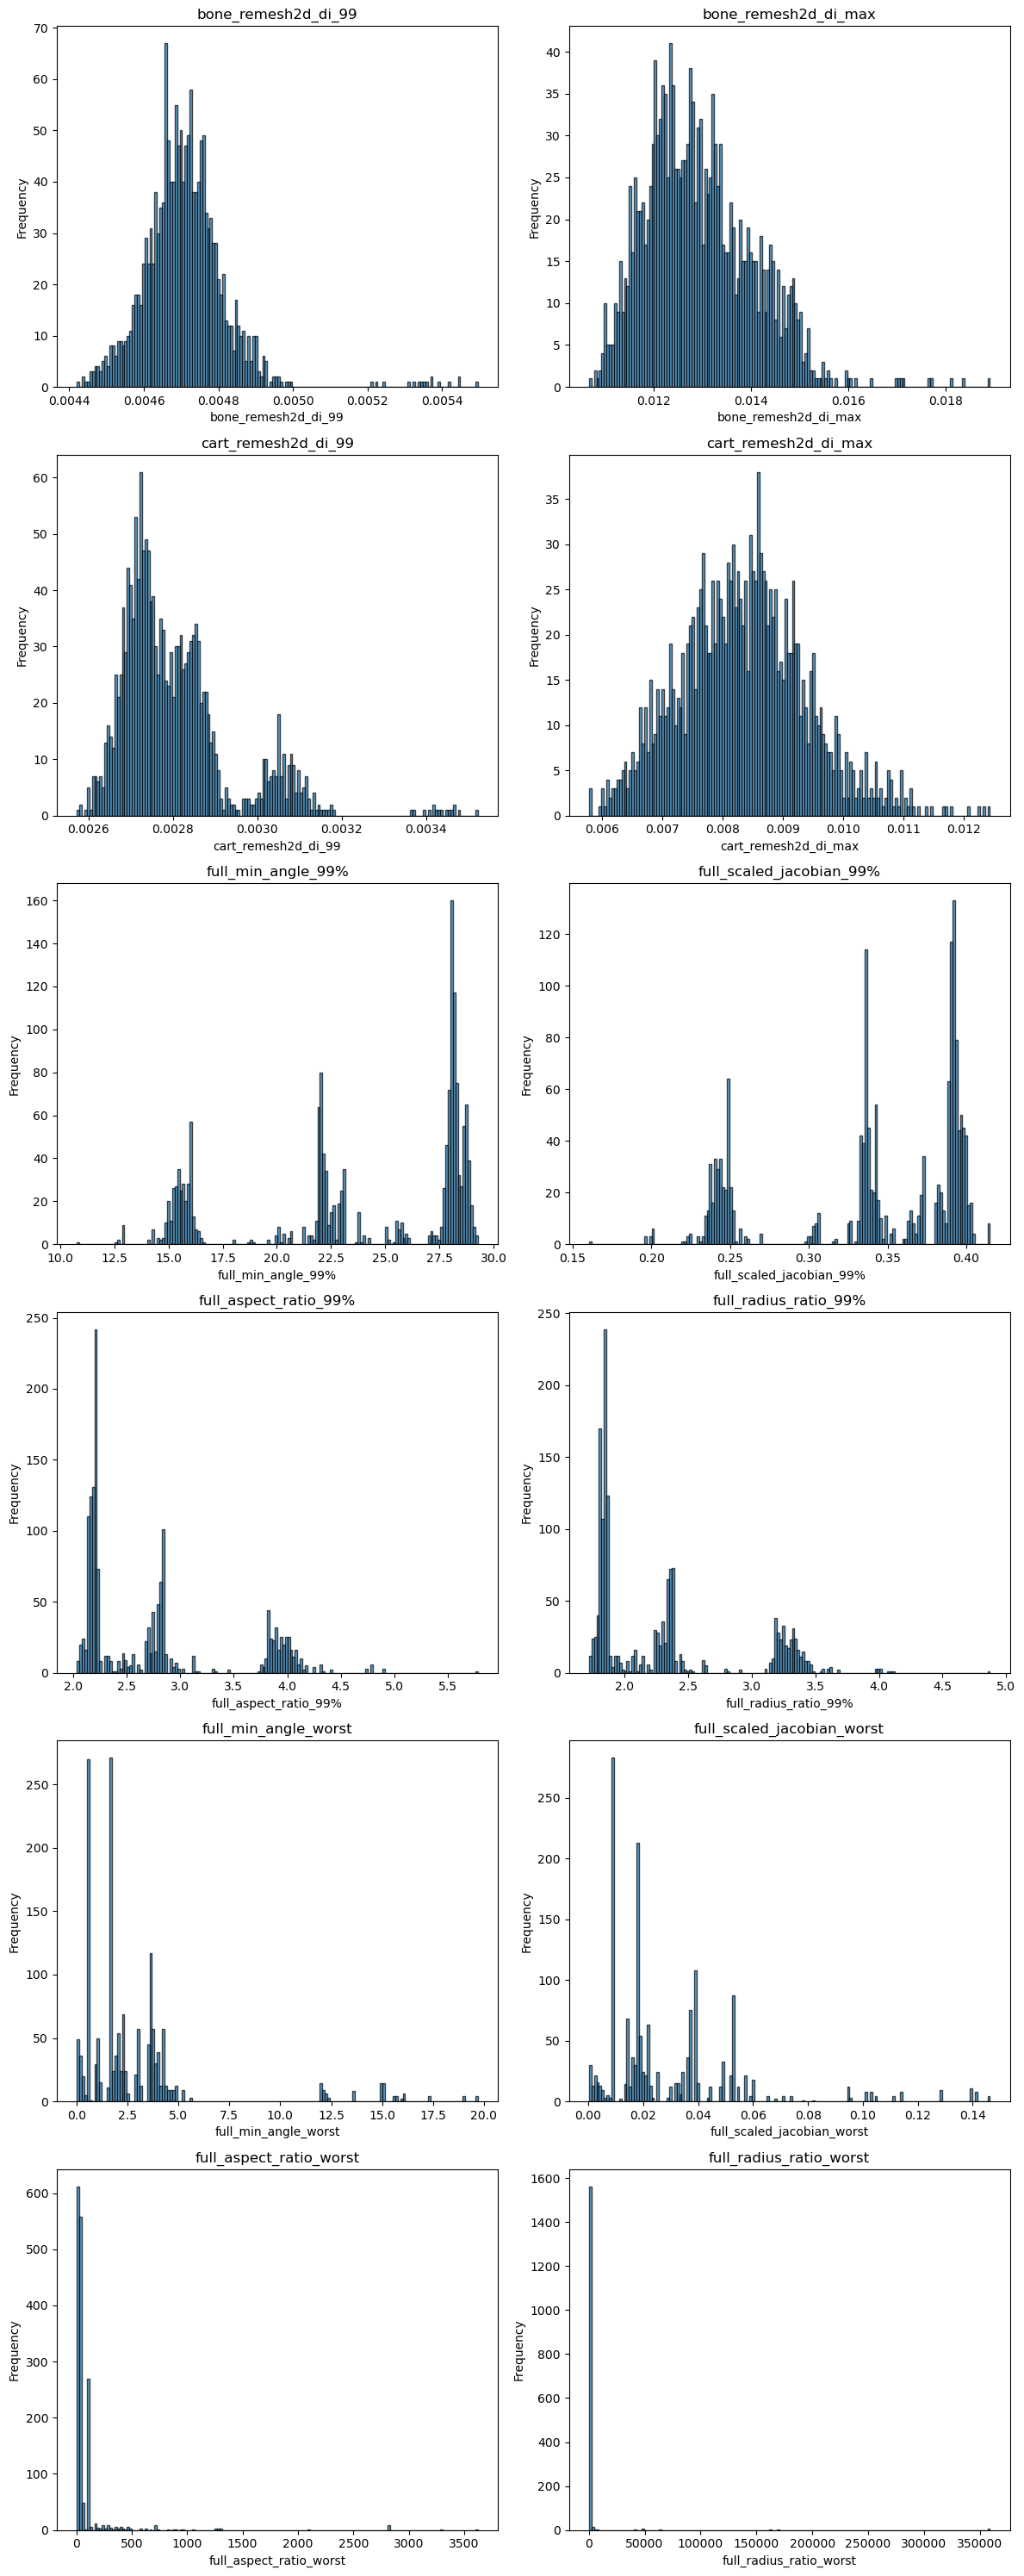

In [6]:
fig, ax = plt.subplots(6, 2, figsize=(12, 30))
ax = ax.flatten()

most_cells = qual.sort_values('full_n_cells').iloc[-1]
print(f'Highest element count:\n\t{most_cells['sub']} - {most_cells['full_n_cells']}')
for sub in df['sub'].unique():
    subject, side = sub[:-1], sub[-1]
    stl_path = get_subject_stl_path(subject, side)
    orig_bone = get_mesh(stl_path, 'tpm')
    L = avg_edge_length(orig_bone)
    #print(f"\n{sub}\n - Average edge length: {L:.4f} mm")
    #print(f' -   Max element count: {qual[qual['sub']==sub]['total_tets'].max()}')

    sub_df = df[df['sub']==sub]
    bins = int(len(df) / 10)
    for i, metric in enumerate(metrics):
        values = sub_df[metric]#[df_param['fd_bone']==0.8]
        # Histogram
        ax[i].hist(values, bins=bins, edgecolor='black', alpha=0.7, label=sub)
        ax[i].set_title(metric)
        ax[i].set_xlabel(metric)
        ax[i].set_ylabel('Frequency')

        #ax[i].legend()

plt.tight_layout()
plt.show()

In [7]:
q_weight = 1 

chosen_metrics = {

    f'{qual_part}_min_angle_99%': {
        'ideal': 30,
        'acceptable': 15,
        'weight': q_weight
    },

    f'{qual_part}_scaled_jacobian_99%': {
        'ideal': 0.4,
        'acceptable': 0.3,
        'weight': q_weight
    },

    f'{qual_part}_aspect_ratio_99%': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q_weight
    },

    f'{qual_part}_radius_ratio_99%': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q_weight
    },

    f'{qual_part}_min_angle_worst': {
        'ideal': 15,
        'acceptable': 10,
        'weight': q_weight
    },

    f'{qual_part}_scaled_jacobian_worst': {
        'ideal': 0.3,
        'acceptable': 0.2,
        'weight': q_weight
    },

    f'{qual_part}_aspect_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q_weight
    },

    f'{qual_part}_radius_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q_weight
    },
}

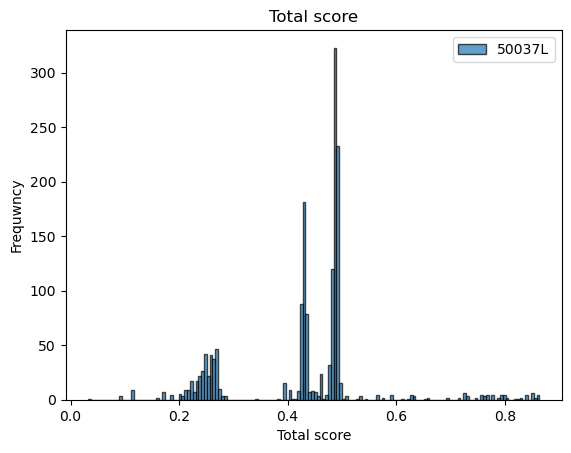

In [8]:
# Get scores

decay = 3
linear_floor = 0.5
total_weight = sum([w['weight'] for w in chosen_metrics.values()])

df_score = df[['sub', 'bone', 'run_id']].copy()
total = 0
for metric, bounds in chosen_metrics.items():
    score = score_value(df[metric], bounds['ideal'], bounds['acceptable'], linear_floor, decay)
    df_score[metric] = score
    total += score * bounds['weight'] / total_weight
df_score['total'] = total
df_score['rank_within_case'] = (
    df_score.groupby(['sub', 'bone'])['total']
    .rank(ascending=False, method='average')
)

# Merge with params

df_score = df_score.sort_values('total', ascending=False)

df_score_param = df_score.merge(
    df_param,
    on=['sub', 'bone', 'run_id'],
    how='left'
)
df_score_qual = df_score.merge(
    df_qual,
    on=['sub', 'bone', 'run_id'],
    how='left'
)

# Plot overall scores
fig, ax = plt.subplots()

subs = df_score['sub'].unique()
for sub in subs:
    sub_df = df_score[df_score['sub'] == sub]

    ax.hist(sub_df['total'], bins=round(len(df_score)/10), edgecolor='black', alpha=0.7, label=sub)

    ax.set_title("Total score")
    ax.set_xlabel('Total score')
    ax.set_ylabel('Frequwncy')
    ax.legend()

In [13]:
# Best accross all subjects

df_grouped_rank = (
    df_score_param
    .groupby(df_param.columns[3:].to_list(), dropna=False)
    .agg(
        mean_rank=('rank_within_case', 'mean'),
        median_rank=('rank_within_case', 'median'),
        best_rank=('rank_within_case', 'min'),
        n_runs=('rank_within_case', 'size')
    )
    .reset_index()
    .sort_values('mean_rank')
)
df_grouped_rank

,cgal_params.optimisation.odt,cgal_params.optimisation.lloyd,cgal_params.optimisation.perturb,cgal_params.optimisation.exude,cgal_params.odt.max_iteration_number,cgal_params.odt.freeze_bound,cgal_params.lloyd.max_iteration_number,cgal_params.lloyd.freeze_bound,cgal_params.perturb.sliver_bound,cgal_params.exude.sliver_bound,mean_rank,median_rank,best_rank,n_runs
256,True,False,True,True,25.0,0.001,0.0,0.000,30.0,0.0,1.0,1.0,1.0,1
258,True,False,True,True,25.0,0.001,0.0,0.000,30.0,30.0,2.0,2.0,2.0,1
253,True,False,True,True,25.0,0.001,0.0,0.000,15.0,0.0,3.0,3.0,3.0,1
255,True,False,True,True,25.0,0.001,0.0,0.000,15.0,30.0,4.0,4.0,4.0,1
1552,True,True,True,True,100.0,0.010,25.0,0.001,30.0,0.0,5.0,5.0,5.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52,False,True,True,False,0.0,0.000,5.0,0.001,0.0,0.0,1595.0,1595.0,1595.0,1
18,False,True,False,False,0.0,0.000,5.0,0.010,0.0,0.0,1597.0,1597.0,1597.0,1
17,False,True,False,False,0.0,0.000,5.0,0.005,0.0,0.0,1598.0,1598.0,1598.0,1
16,False,True,False,False,0.0,0.000,5.0,0.001,0.0,0.0,1599.0,1599.0,1599.0,1


In [37]:
sub = '50037L'
df_score_param[(df_score_param['sub']==sub)][[x for x in df_score_param.columns if 'worst' not in x]].head(10)

,sub,bone,run_id,full_min_angle_99%,full_scaled_jacobian_99%,full_aspect_ratio_99%,full_radius_ratio_99%,total,rank_within_case,cgal_params.optimisation.odt,cgal_params.optimisation.lloyd,cgal_params.optimisation.perturb,cgal_params.optimisation.exude,cgal_params.odt.max_iteration_number,cgal_params.odt.freeze_bound,cgal_params.lloyd.max_iteration_number,cgal_params.lloyd.freeze_bound,cgal_params.perturb.sliver_bound,cgal_params.exude.sliver_bound
0,50037L,tpm,0-0-51-0e,0.970330,0.864816,1.0,1.0,0.863779,1.0,True,False,True,True,25.0,0.001,0.0,0.000,30.0,0.0
1,50037L,tpm,0-0-53-0e,0.969180,0.864927,1.0,1.0,0.863649,2.0,True,False,True,True,25.0,0.001,0.0,0.000,30.0,30.0
2,50037L,tpm,0-0-48-0e,0.965936,0.856384,1.0,1.0,0.862760,3.0,True,False,True,True,25.0,0.001,0.0,0.000,15.0,0.0
3,50037L,tpm,0-0-50-0e,0.964784,0.855970,1.0,1.0,0.862564,4.0,True,False,True,True,25.0,0.001,0.0,0.000,15.0,30.0
4,50037L,tpm,0-0-537-0a,0.945159,1.000000,1.0,1.0,0.854825,5.0,True,True,True,True,100.0,0.010,25.0,0.001,30.0,0.0
5,50037L,tpm,0-0-539-0a,0.940487,1.000000,1.0,1.0,0.854241,6.0,True,True,True,True,100.0,0.010,25.0,0.001,30.0,30.0
6,50037L,tpm,0-0-294-0a,0.949495,1.000000,1.0,1.0,0.853084,7.0,True,True,True,True,25.0,0.010,25.0,0.001,30.0,0.0
7,50037L,tpm,0-0-296-0a,0.943570,1.000000,1.0,1.0,0.852343,8.0,True,True,True,True,25.0,0.010,25.0,0.001,30.0,30.0
8,50037L,tpm,0-0-75-0e,0.965579,0.825375,1.0,1.0,0.850095,9.0,True,False,True,True,100.0,0.001,0.0,0.000,15.0,0.0
9,50037L,tpm,0-0-77-0e,0.963228,0.824906,1.0,1.0,0.849742,10.0,True,False,True,True,100.0,0.001,0.0,0.000,15.0,30.0


In [32]:
df_score_qual[(df_score_qual['sub']==sub)][['sub', 'bone', 'run_id']+[x for x in df_score_qual.columns if '_y' in x]].head(7)

,sub,bone,run_id,full_min_angle_worst_y,full_min_angle_99%_y,full_radius_ratio_worst_y,full_radius_ratio_99%_y,full_aspect_ratio_worst_y,full_aspect_ratio_99%_y,full_scaled_jacobian_worst_y,full_scaled_jacobian_99%_y
0,50037L,tpm,0-0-51-0e,18.999501,29.109909,4.049454,1.722309,3.645425,2.048180,0.146289,0.372963
1,50037L,tpm,0-0-53-0e,18.999501,29.075414,4.049454,1.727726,3.645425,2.057113,0.146289,0.372985
2,50037L,tpm,0-0-48-0e,15.094866,28.978091,4.011842,1.733208,3.891657,2.058807,0.141202,0.371277
3,50037L,tpm,0-0-50-0e,15.094866,28.943510,4.011842,1.737096,3.891657,2.067950,0.141202,0.371194
4,50037L,tpm,0-0-537-0a,15.664385,28.354759,4.067568,1.814788,4.220231,2.168728,0.113516,0.400171
5,50037L,tpm,0-0-539-0a,15.664385,28.214601,4.067568,1.823338,4.220231,2.182915,0.113516,0.400167
6,50037L,tpm,0-0-294-0a,16.014618,28.484845,4.063158,1.811642,4.262478,2.164141,0.114093,0.400610


# Thoughts
 - addition of ODT gives ~20% improvment to min angle - and makes mesh look nicer
 - suggests the same pattern for perturb and exude 
    - perturb higher than is achievable and exude = 0
 - suggests that the addition of some but not too much odt is better
     - 25 iterations at 0.001 freeze_bound
         - this is the lowest freeze_bound tried
---
### Plan (study2)
- Run all 3 of the subjects with the established:
    - perturb = ≥ 20
    - exude = 0
    - lloyd: 
        - iterations = [15, 30, 45, 100]
        - freeze_bound = [0.001, 0.0005, 0.0001]


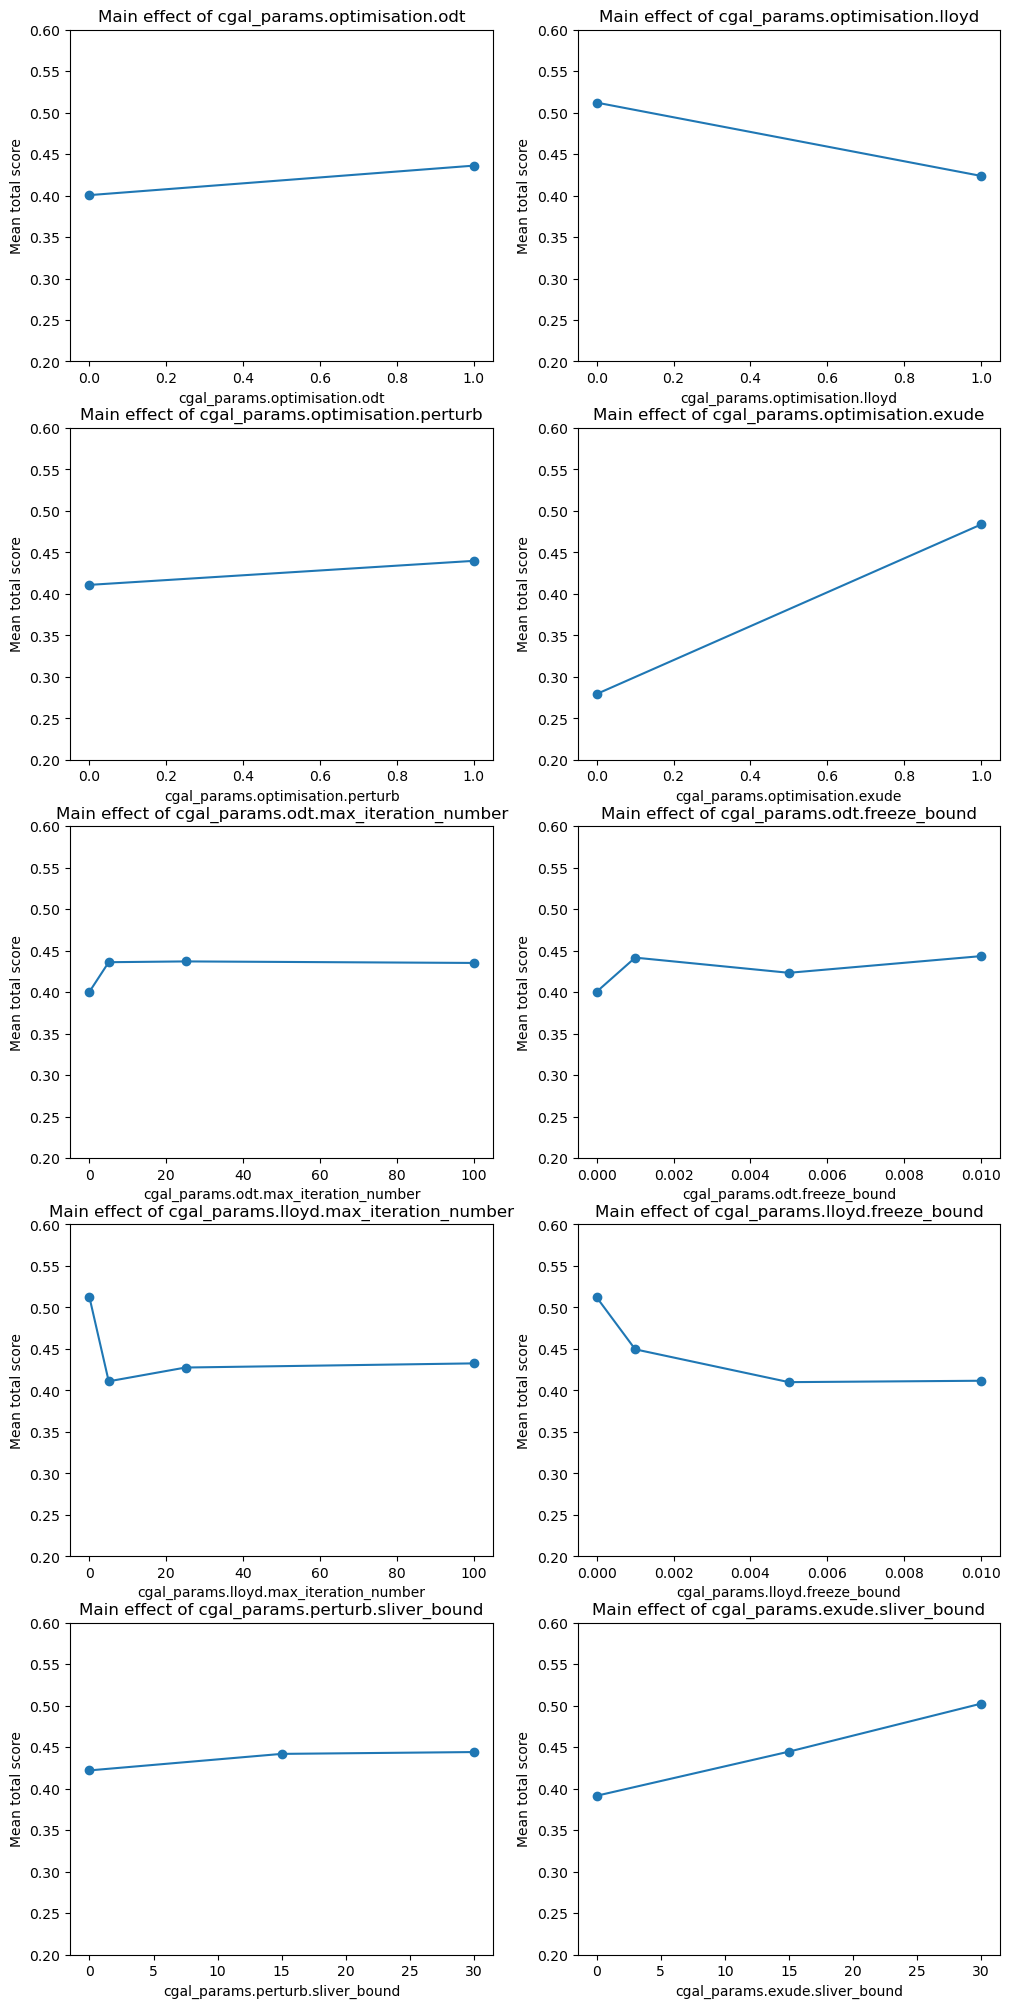

In [ ]:
nrows, ncols = 5, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
ax = ax.flatten()

for i, p in enumerate(df_param.columns[3:]):
    eff = (
        df_score_param
        .groupby(p)['total']
        .mean()
        .reset_index()
        .sort_values(p)
    )

    ax[i].plot(eff[p], eff['total'], marker='o')
    ax[i].set_title(f'Main effect of {p}')
    ax[i].set_xlabel(p)
    ax[i].set_ylabel('Mean total score')

    ax[i].set_ylim([0.2, 0.6])

# THIS SUGGESTS THAT EXUDE sliver_bound = 0 ISN'T GOOD BUT THAT IS ONLY BECAUSE NAN VALUES WERE SET TO 0

In [34]:
# 51e
mesh = pv.read('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/outputs/ParamOptimisation/optimiseV2/optCombos-study1e/meshes/50037L/tpm-mc1/3Dmesh/mesh-0-0-51.vtu')

mesh.plot()

Widget(value='<iframe src="http://localhost:62997/index.html?ui=P_0x30b2a2e70_0&reconnect=auto" class="pyvista…